libaraies

In [1]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

load files

In [2]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"
RI1_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s2_3_p5_3_nRB3_20250622_104059_merged (1).h5"
RI2_2_3_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s2_3_p5_3_nRB3_20250622_110216_merged.h5"
RI1_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_8_p5_1_nRB3_20250621_165214_merged.h5"
RI2_4_8_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_8_p5_1_nRB3_20250621_171318_merged.h5"

# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
RI1_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s2_3_p5_3_nRB3_20250622_104059.1.csv")
RI2_2_3_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s2_3_p5_3_nRB3_20250622_1102116.1.csv")
RI1_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_8_p5_1_nRB3_HEEPS.csv")
RI2_4_8_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_8_p5_1_nRB3_20250621_HEEPS.csv")

In [3]:
# RI2 H5 paths
ri2_h5_paths = {
    "RI2_3_6": RI2_3_6_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI2_4_8": RI2_4_8_h5_path,
}

# RI2 BORIS data
ri2_boris_data = {
    "RI2_3_6": RI2_3_6_boris.copy(),
    "RI2_4_7": RI2_4_7_boris.copy(),
    "RI2_2_3": RI2_2_3_boris.copy(),
    "RI2_4_8": RI2_4_8_boris.copy(),
}


In [4]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate

In [5]:
# Dictionary of H5 files with labels for tracking
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "BLRI_s3_6": BLRI_s3_6_h5_path,
    "BLRI_s4_7": BLRI_s4_7_h5_path,
    "RI1_4_7": RI_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path
}

# Create a dictionary to store results
resp_data = {}

# Loop through files and apply the function
for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing BLRI_s3_6...
Processing BLRI_s4_7...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
All available signals loaded.


In [95]:
def calculate_latency_and_ibi_change(df, resp_signal, resp_times, sampling_rate=100):
    import numpy as np
    from scipy.signal import find_peaks

    # Ensure time columns numeric
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)

    # Sort by start time
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Select social_agent facial sniffs and fights
    sniff_df = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')]
    fight_df = df[df['Behavior'] == 'fighting']

    # Detect breath peaks for IBI calculation
    peaks, _ = find_peaks(resp_signal, distance=int(sampling_rate * 0.15))  # minimum 150 ms apart
    peak_times = resp_times[peaks]
    ibis = np.diff(peak_times)
    ibi_times = peak_times[:-1]  # time assigned to each IBI (start of interval)

    results = []

    for _, sniff in sniff_df.iterrows():
        sniff_start = sniff['Start (s)']
        sniff_end = sniff['Stop (s)']

        # Find next fight after sniff end
        future_fights = fight_df[fight_df['Start (s)'] > sniff_end]
        if not future_fights.empty:
            fight_start = future_fights.iloc[0]['Start (s)']
            latency = fight_start - sniff_end
        else:
            fight_start = None
            latency = None

        # Calculate baseline and post IBI means
        baseline_mask = (ibi_times >= sniff_start - 1.5) & (ibi_times < sniff_start - 0.5)
        post_mask = (ibi_times >= sniff_start + 0.5) & (ibi_times < sniff_start + 1.5)

        baseline_ibi = ibis[baseline_mask]
        post_ibi = ibis[post_mask]

        if len(baseline_ibi) == 0 or len(post_ibi) == 0:
            percent_ibi_change = np.nan
        else:
            percent_ibi_change = 100 * (np.mean(post_ibi) - np.mean(baseline_ibi)) / np.mean(baseline_ibi)

        results.append({
            'Sniff Start': sniff_start,
            'Sniff End': sniff_end,
            'Fight Start': fight_start,
            'Latency to Fight (s)': latency,
            '% IBI Change': percent_ibi_change
        })

    return pd.DataFrame(results)


In [96]:
result_df = calculate_latency_and_ibi_change(df, resp_signal, resp_times, sampling_rate=fs)

if result_df is None or result_df.empty:
    print(f"  Skipping {subject}: no valid analysis output.")
    continue

result_df["Subject"] = subject
all_ri2_results.append(result_df)


SyntaxError: 'continue' not properly in loop (276585007.py, line 5)

In [ ]:
for subject, df in ri2_boris_data.items():
    count = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')].shape[0]
    print(f"{subject} facial sniffing count: {count}")


RI2_3_6 facial sniffing count: 26
RI2_4_7 facial sniffing count: 21
RI2_2_3 facial sniffing count: 12
RI2_4_8 facial sniffing count: 38


In [ ]:
for subject, df in ri2_boris_data.items():
    count = df[df['Behavior'] == 'fighting'].shape[0]
    print(f"{subject} fight count: {count}")


RI2_3_6 fight count: 18
RI2_4_7 fight count: 30
RI2_2_3 fight count: 14
RI2_4_8 fight count: 28


In [ ]:
from scipy.signal import find_peaks

for subject, resp_file in ri2_h5_paths.items():
    resp_signal, resp_times, fs = load_clean_resp_signal(resp_file, target_rate=100)
    if resp_signal is None:
        print(f"{subject}: Resp signal failed to load.")
        continue
    peaks, _ = find_peaks(resp_signal, distance=int(fs * 0.15))
    print(f"{subject}: {len(peaks)} peaks found in respiration signal.")


RI2_3_6: 2788 peaks found in respiration signal.
RI2_4_7: 2819 peaks found in respiration signal.
RI2_2_3: 2718 peaks found in respiration signal.
RI2_4_8: 2846 peaks found in respiration signal.


load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [6]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter respiration signal in typical breathing freq range
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=5,  # narrower band for respiration (~0.1 - 5 Hz)
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate


def detect_breath_peaks(resp_signal, time_vector, sampling_rate=100):
    """
    Detect breath peaks in cleaned respiration signal.
    """
    peaks, _ = find_peaks(resp_signal, distance=int(sampling_rate * 0.15))  # min 150ms apart
    peak_times = time_vector[peaks]
    return peaks, peak_times


def calculate_ibi(peak_times):
    """
    Calculate inter-breath intervals from detected breath peak times.
    """
    ibis = np.diff(peak_times)
    ibi_times = peak_times[:-1]  # IBI timestamp = start of interval
    return ibi_times, ibis


def get_percent_change_ibi(ibi_times, ibis, event_time):
    """
    Calculate % change in mean IBI for windows:
    Baseline: -1.5 to -0.5 s before event
    Post: +0.5 to +1.5 s after event
    
    Returns np.nan if insufficient data.
    """
    baseline_mask = (ibi_times >= event_time - 1.5) & (ibi_times < event_time - 0.5)
    post_mask = (ibi_times >= event_time + 0.5) & (ibi_times < event_time + 1.5)

    baseline_ibi = ibis[baseline_mask]
    post_ibi = ibis[post_mask]

    if len(baseline_ibi) == 0 or len(post_ibi) == 0:
        return np.nan

    baseline_mean = np.mean(baseline_ibi)
    post_mean = np.mean(post_ibi)

    percent_change = 100 * (post_mean - baseline_mean) / baseline_mean
    return percent_change


def calculate_agent_sniff_to_fight_latency(df, resp_signal, resp_times, sampling_rate=100):
    """
    Calculate latency from sniff to fight and % change in IBI around sniff start.
    """
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)

    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    sniff_df = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')]
    fight_df = df[df['Behavior'] == 'fighting']

    # Detect breath peaks and compute IBIs once per call to save time
    peaks, peak_times = detect_breath_peaks(resp_signal, resp_times, sampling_rate)
    ibi_times, ibis = calculate_ibi(peak_times)

    latencies = []

    for _, sniff in sniff_df.iterrows():
        sniff_start = sniff['Start (s)']
        sniff_end = sniff['Stop (s)']

        # Find the first fight after sniff ends
        future_fights = fight_df[fight_df['Start (s)'] > sniff_end]

        if not future_fights.empty:
            next_fight = future_fights.iloc[0]
            latency = next_fight['Start (s)'] - sniff_end
            fight_start = next_fight['Start (s)']
        else:
            latency = None
            fight_start = None

        # Calculate % change in IBI around sniff start
        percent_ibi_change = get_percent_change_ibi(ibi_times, ibis, sniff_start)

        latencies.append({
            'Sniff Start Time (s)': sniff_start,
            'Sniff End Time (s)': sniff_end,
            'Fight Start Time (s)': fight_start,
            'Latency (s)': latency,
            '% IBI Change': percent_ibi_change
        })

    return pd.DataFrame(latencies)


Processing RI1_3_6...
Processing RI2_3_6...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...


C:\Users\sjs93\AppData\Local\Temp\ipykernel_48436\3252379249.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df = pd.concat(all_results, ignore_index=True)


   Sniff Start Time (s)  Sniff End Time (s)  Fight Start Time (s)  \
0                12.069              12.862                   NaN   
1                86.207              87.414                   NaN   
2                88.034              88.828                   NaN   
3               107.724             108.483                   NaN   
4               183.724             184.621                   NaN   

   Latency (s)  % IBI Change  Subject  
0          NaN     21.651786  RI1_3_6  
1          NaN     10.588235  RI1_3_6  
2          NaN    -13.600000  RI1_3_6  
3          NaN      2.173913  RI1_3_6  
4          NaN    -23.853211  RI1_3_6  


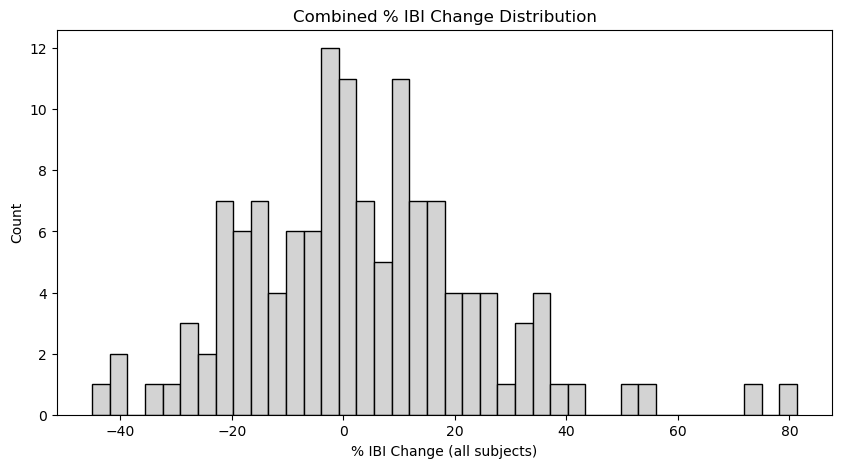

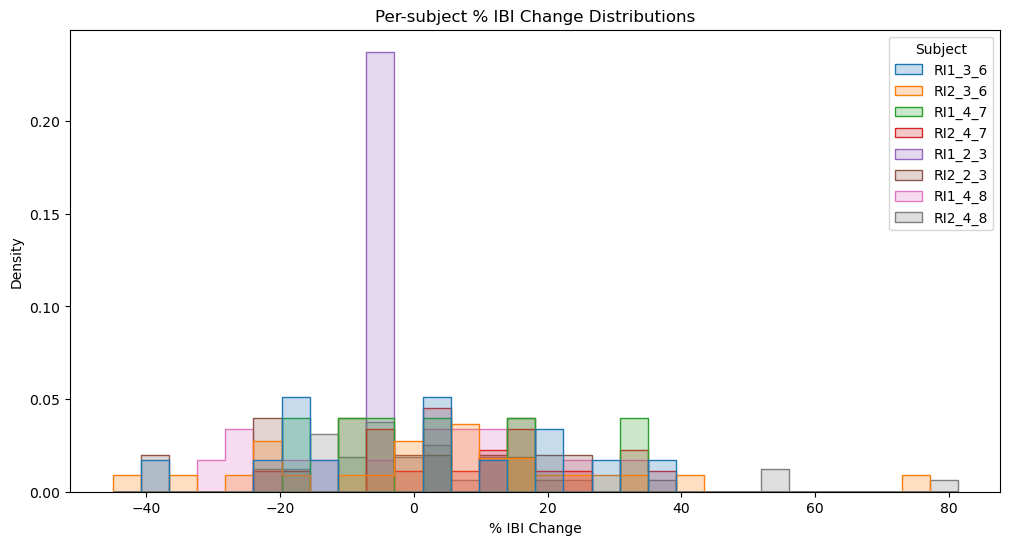

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a list of tuples (resp file path, behavior DataFrame, subject label)
datasets = [
    (RI1_3_6_h5_path, RI1_3_6_boris.copy(), 'RI1_3_6'),
    (RI2_3_6_h5_path, RI2_3_6_boris.copy(), 'RI2_3_6'),
    (RI_4_7_h5_path, RI1_4_7_boris.copy(), 'RI1_4_7'),
    (RI2_4_7_h5_path, RI2_4_7_boris.copy(), 'RI2_4_7'),
    (RI1_2_3_h5_path, RI1_2_3_boris.copy(), 'RI1_2_3'),
    (RI2_2_3_h5_path, RI2_2_3_boris.copy(), 'RI2_2_3'),
    (RI1_4_8_h5_path, RI1_4_8_boris.copy(), 'RI1_4_8'),
    (RI2_4_8_h5_path, RI2_4_8_boris.copy(), 'RI2_4_8'),
]

all_results = []

for resp_path, behavior_df, subj in datasets:
    print(f"Processing {subj}...")
    
    # Ensure required columns exist or rename here if needed
    # Example rename if your CSV columns differ:
    # behavior_df.rename(columns={'Start Time (s)': 'Start (s)', 'Stop Time (s)': 'Stop (s)'}, inplace=True)
    
    # Load and clean resp
    resp_signal, resp_times, fs = load_clean_resp_signal(resp_path, target_rate=100)
    
    # Run analysis
    result_df = calculate_agent_sniff_to_fight_latency(behavior_df, resp_signal, resp_times, sampling_rate=fs)
    result_df['Subject'] = subj
    
    all_results.append(result_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Print summary
print(combined_df.head())

# Plot combined % IBI Change distribution
plt.figure(figsize=(10,5))
plt.hist(combined_df['% IBI Change'].dropna(), bins=40, color='lightgray', edgecolor='black')
plt.xlabel('% IBI Change (all subjects)')
plt.ylabel('Count')
plt.title('Combined % IBI Change Distribution')
plt.show()

# Plot per-subject distributions
import seaborn as sns

plt.figure(figsize=(12,6))
sns.histplot(data=combined_df, x='% IBI Change', hue='Subject', element='step', stat='density', common_norm=False, bins=30)
plt.xlabel('% IBI Change')
plt.title('Per-subject % IBI Change Distributions')
plt.show()


In [8]:
# 1. Load your respiration signal
resp_signal, resp_times, fs = load_clean_resp_signal(your_h5_path, target_rate=100)

# 2. Load behavior df with columns: 'Start (s)', 'Stop (s)', 'Behavior', 'Subject'
# e.g. df = pd.read_csv(your_boris_csv)

# 3. Run analysis
results_df = calculate_latency_and_ibi_change(df, resp_signal, resp_times, sampling_rate=fs)

print(results_df.head())


NameError: name 'your_h5_path' is not defined

In [9]:
# Dictionary of H5 files with labels for tracking
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "BLRI_s3_6": BLRI_s3_6_h5_path,
    "BLRI_s4_7": BLRI_s4_7_h5_path,
    "RI1_4_7": RI_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path
}

In [13]:
# Load and clean resp signal
resp_signal, resp_times, fs = load_clean_resp_signal('h5_paths', target_rate=100)

# Load your behavioral data (df), then run:
result_df = calculate_agent_sniff_to_fight_latency(results_df, resp_signal, resp_times, sampling_rate=fs)
print(result_df)


Error loading h5_paths: [Errno 2] Unable to synchronously open file (unable to open file: name = 'h5_paths', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)


NameError: name 'results_df' is not defined

Loop through files

In [14]:
# Dictionary of H5 files with labels for tracking
h5_paths = {
    "RI1_3_6": RI1_3_6_h5_path,
    "RI2_3_6": RI2_3_6_h5_path,
    "BLRI_s3_6": BLRI_s3_6_h5_path,
    "BLRI_s4_7": BLRI_s4_7_h5_path,
    "RI1_4_7": RI_4_7_h5_path,
    "RI2_4_7": RI2_4_7_h5_path,
    "RI1_2_3": RI1_2_3_h5_path,
    "RI2_2_3": RI2_2_3_h5_path,
    "RI1_4_8": RI1_4_8_h5_path,
    "RI2_4_8": RI2_4_8_h5_path
}

# Create a dictionary to store results
resp_data = {}

# Loop through files and apply the function
for label, path in h5_paths.items():
    print(f"Processing {label}...")
    signal, time, rate = load_clean_resp_signal(path)
    if signal is not None:
        resp_data[label] = {
            "signal": signal,
            "time": time,
            "sampling_rate": rate
        }
    else:
        print(f"Skipping {label}: failed to load.")

print("All available signals loaded.")


Processing RI1_3_6...
Processing RI2_3_6...
Processing BLRI_s3_6...
Processing BLRI_s4_7...
Processing RI1_4_7...
Processing RI2_4_7...
Processing RI1_2_3...
Processing RI2_2_3...
Processing RI1_4_8...
Processing RI2_4_8...
All available signals loaded.


In [15]:
for label, path in h5_paths.items():
    print(f"{label} is type {type(path)}")


RI1_3_6 is type <class 'str'>
RI2_3_6 is type <class 'str'>
BLRI_s3_6 is type <class 'str'>
BLRI_s4_7 is type <class 'str'>
RI1_4_7 is type <class 'str'>
RI2_4_7 is type <class 'str'>
RI1_2_3 is type <class 'str'>
RI2_2_3 is type <class 'str'>
RI1_4_8 is type <class 'str'>
RI2_4_8 is type <class 'str'>


In [16]:
for key in resp_data:
    print(f"{key}: {len(resp_data[key]['signal'])} samples at {resp_data[key]['sampling_rate']} Hz")


RI1_3_6: 60328 samples at 100 Hz
RI2_3_6: 61001 samples at 100 Hz
BLRI_s3_6: 60629 samples at 100 Hz
BLRI_s4_7: 60409 samples at 100 Hz
RI1_4_7: 62916 samples at 100 Hz
RI2_4_7: 60647 samples at 100 Hz
RI1_2_3: 60295 samples at 100 Hz
RI2_2_3: 60921 samples at 100 Hz
RI1_4_8: 60484 samples at 100 Hz
RI2_4_8: 60324 samples at 100 Hz


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [ ]:
def get_sniff_respiratory_rate(signal, time, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout.
    """
    sniff_mask = (time >= sniff_start) & (time < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

Explanation
Inputs: A pandas DataFrame with behavioral events and their start/stop times, behavior labels, and subject identifiers.

Process:

Convert start and stop times to float for consistency.

Sort all events chronologically.

Filter for social agent facial sniffing and fighting events.

For each sniff event, find the next fight event that occurs after sniffing ends.

Calculate the latency as the time difference between sniff end and fight start.

If no fight follows, latency is recorded as None.

Output: A DataFrame summarizing sniff times, fight start times, and latency between them.



In [17]:
def calculate_agent_sniff_to_fight_latency(df):
    # Ensure correct data types
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)

    # Sort by time
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Agent-initiated face sniffs
    sniff_df = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')]

    # All fights (you can restrict to social_agent if needed)
    fight_df = df[df['Behavior'] == 'fighting']

    latencies = []

    for _, sniff in sniff_df.iterrows():
        sniff_start = sniff['Start (s)']
        sniff_end = sniff['Stop (s)']
        
        # Find the first fight *after* this sniff ends
        future_fights = fight_df[fight_df['Start (s)'] > sniff_end]
        
        if not future_fights.empty:
            next_fight = future_fights.iloc[0]
            latency = next_fight['Start (s)'] - sniff_end
            latencies.append({
                'Sniff Start Time (s)': sniff_start,
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': next_fight['Start (s)'],
                'Latency (s)': latency
            })
        else:
            latencies.append({
                'Sniff Start Time (s)': sniff_start,
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': None,
                'Latency (s)': None
            })

    return pd.DataFrame(latencies)

In [18]:
# Store results for all mice
all_latencies = []

# Loop over BORIS data
boris_data = {
    "RI2_3_6": RI2_3_6_boris,
    "RI2_4_7": RI2_4_7_boris,
    "RI2_2_3": RI2_2_3_boris,
    "RI2_4_8": RI2_4_8_boris
}

for mouse_id, df in boris_data.items():
    print(f"Processing {mouse_id}...")
    latency_df = calculate_agent_sniff_to_fight_latency(df)
    latency_df["Mouse"] = mouse_id
    all_latencies.append(latency_df)

# Combine into one DataFrame
all_mice_df = pd.concat(all_latencies, ignore_index=True)

# Preview
print(all_mice_df.head())


Processing RI2_3_6...
Processing RI2_4_7...
Processing RI2_2_3...
Processing RI2_4_8...
   Sniff Start Time (s)  Sniff End Time (s)  Fight Start Time (s)  \
0                25.600              26.100                70.833   
1                68.767              69.600                70.833   
2                91.900              92.267               201.867   
3               153.900             154.400               201.867   
4               156.233             156.567               201.867   

   Latency (s)    Mouse  
0       44.733  RI2_3_6  
1        1.233  RI2_3_6  
2      109.600  RI2_3_6  
3       47.467  RI2_3_6  
4       45.300  RI2_3_6  


In [19]:
all_latencies

[    Sniff Start Time (s)  Sniff End Time (s)  Fight Start Time (s)  \
 0                 25.600              26.100                70.833   
 1                 68.767              69.600                70.833   
 2                 91.900              92.267               201.867   
 3                153.900             154.400               201.867   
 4                156.233             156.567               201.867   
 5                195.433             195.767               201.867   
 6                196.167             197.500               201.867   
 7                218.300             219.367               220.233   
 8                226.433             226.900               227.033   
 9                234.867             235.367               272.100   
 10               249.733             250.567               272.100   
 11               257.833             258.367               272.100   
 12               267.400             268.933               272.100   
 13   

In [20]:
all_mice_df

,Sniff Start Time (s),Sniff End Time (s),Fight Start Time (s),Latency (s),Mouse
0,25.600,26.100,70.833,44.733,RI2_3_6
1,68.767,69.600,70.833,1.233,RI2_3_6
2,91.900,92.267,201.867,109.600,RI2_3_6
3,153.900,154.400,201.867,47.467,RI2_3_6
4,156.233,156.567,201.867,45.300,RI2_3_6
5,195.433,195.767,201.867,6.100,RI2_3_6
6,196.167,197.500,201.867,4.367,RI2_3_6
7,218.300,219.367,220.233,0.866,RI2_3_6
8,226.433,226.900,227.033,0.133,RI2_3_6
9,234.867,235.367,272.100,36.733,RI2_3_6


In [21]:
# === Process one BORIS files ===
boris_df = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
latency_df = calculate_agent_sniff_to_fight_latency(boris_df)
print(latency_df)

    Sniff Start Time (s)  Sniff End Time (s)  Fight Start Time (s)  \
0                  6.767               7.667                15.733   
1                 13.767              14.967                15.733   
2                 29.633              30.367                38.167   
3                 37.567              37.867                38.167   
4                 66.300              68.133               105.467   
5                 99.333             100.099               105.467   
6                104.067             105.099               105.467   
7                298.300             304.800               305.533   
8                334.867             334.933               338.633   
9                409.867             410.100               430.800   
10               454.000             454.699               454.700   
11               471.633             472.133               522.067   
12               472.367             475.033               522.067   
13               495

Explanation of get_respiratory_rate
This function calculates the change in breathing rate (in Hertz) immediately surrounding a specific sniff event.

Inputs:

signal: The respiratory signal array, typically representing breathing-related measurements over time.

times: A time vector corresponding to the signal samples.

sniff_time: The time point of interest (e.g., the moment a sniff starts or ends).

sampling_rate: How many samples per second the signal was recorded at (default 100 Hz).

window: Duration in seconds before and after the sniff time to analyze (default 2 seconds).

What it does:

Defines two time windows:

A pre-sniff window (from sniff_time - window up to sniff_time)

A post-sniff window (from sniff_time up to sniff_time + window)

Extracts the respiratory signal segments corresponding to these two windows.

Detects breathing peaks in each segment using a minimum distance between peaks to avoid counting noise or false peaks.

Calculates the breathing rate in each window as the number of detected peaks divided by the window length.

Returns the difference between the post-sniff and pre-sniff breathing rates (delta_rate), representing how much the breathing rate changed right after the sniff event.

Why it’s useful:
This measure helps quantify how sniffing behavior relates to changes in breathing dynamics, which can be important for understanding physiological or behavioral states during social interactions.

In [22]:
def get_respiratory_rate(signal, times, sniff_time, sampling_rate=100, window=2):
    """
    Compute the change in breathing rate (Hz) around a sniff_time.
    """
    # Define time windows
    pre_start = sniff_time - window
    pre_end = sniff_time
    post_start = sniff_time
    post_end = sniff_time + window

    # Create masks
    pre_mask = (times >= pre_start) & (times < pre_end)
    post_mask = (times >= post_start) & (times < post_end)

    # Get segments
    signal_pre = signal[pre_mask]
    signal_post = signal[post_mask]

    # Get rate = number of peaks / duration
    pre_peaks, _ = find_peaks(signal_pre, distance=sampling_rate*0.2)  # 200 ms min gap
    post_peaks, _ = find_peaks(signal_post, distance=sampling_rate*0.2)

    # Compute rate in Hz (peaks per sec)
    rate_pre = len(pre_peaks) / window
    rate_post = len(post_peaks) / window

    delta_rate = rate_post - rate_pre
    return delta_rate

 """
    Calculate the percent change in breathing rate during a sniff period 
    relative to a baseline period before the sniff.

    Parameters:
        signal (np.array): 1D respiratory signal array.
        times (np.array): 1D time array aligned with the signal.
        sniff_start (float): Start time of the sniff window.
        sniff_end (float): End time of the sniff window.
        sampling_rate (int): Sampling rate in Hz (default 100).
        baseline_window (float): Duration of baseline window before sniff_start in seconds (default 4).

    Returns:
        float: Percent change in breathing rate during sniff relative to baseline. NaN if invalid.
    """

In [23]:
def get_percent_change_resp_rate(signal, times, sniff_start, sniff_end, sampling_rate=100, baseline_window=4):
    """
    Calculate the percent change in breathing rate during a sniff period 
    relative to a baseline period before the sniff.

    Parameters:
        signal (np.array): 1D respiratory signal array.
        times (np.array): 1D time array aligned with the signal.
        sniff_start (float): Start time of the sniff window.
        sniff_end (float): End time of the sniff window.
        sampling_rate (int): Sampling rate in Hz (default 100).
        baseline_window (float): Duration of baseline window before sniff_start in seconds (default 4).

    Returns:
        float: Percent change in breathing rate during sniff relative to baseline. NaN if invalid.
    """
    baseline_start = sniff_start - baseline_window
    baseline_end = sniff_start

    # Define masks for baseline and sniff periods
    baseline_mask = (times >= baseline_start) & (times < baseline_end)
    sniff_mask = (times >= sniff_start) & (times < sniff_end)

    signal_baseline = signal[baseline_mask]
    signal_sniff = signal[sniff_mask]

    # Safety check: Ensure there is data in both periods
    if signal_baseline.size == 0 or signal_sniff.size == 0:
        return np.nan

    # Detect peaks (breaths) in each period
    min_distance = int(sampling_rate * 0.2)  # Minimum time between peaks (e.g. 5 Hz = 0.2s)
    peaks_baseline, _ = find_peaks(signal_baseline, distance=min_distance)
    peaks_sniff, _ = find_peaks(signal_sniff, distance=min_distance)

    # Calculate duration of each window
    baseline_duration = baseline_end - baseline_start
    sniff_duration = sniff_end - sniff_start

    if baseline_duration <= 0 or sniff_duration <= 0:
        return np.nan

    # Calculate rates (Hz)
    rate_baseline = len(peaks_baseline) / baseline_duration
    rate_sniff = len(peaks_sniff) / sniff_duration

    if rate_baseline == 0 or np.isnan(rate_baseline):
        return np.nan  # avoid divide by zero

    percent_change = ((rate_sniff - rate_baseline) / rate_baseline) * 100

    # Debug info
    # print(f"Baseline rate: {rate_baseline:.2f} Hz, Sniff rate: {rate_sniff:.2f} Hz, % Change: {percent_change:.2f}%")

    return percent_change


In [24]:
# Add new column for percent change
percent_changes = []

for _, row in all_mice_df.iterrows():
    mouse_id = row["Mouse"]
    sniff_start = row["Sniff Start Time (s)"]
    sniff_end = row["Sniff End Time (s)"]

    # Check that times are valid
    if pd.isna(sniff_start) or pd.isna(sniff_end):
        percent_changes.append(np.nan)
        continue

    # Get corresponding respiration trace
    resp_entry = resp_data.get(mouse_id)
    if resp_entry is None or resp_entry["signal"] is None or resp_entry["time"] is None:
        print(f"Skipping {mouse_id}: missing respiration data")
        percent_changes.append(np.nan)
        continue

    signal = resp_entry["signal"]
    times = resp_entry["time"]
    sampling_rate = resp_entry["sampling_rate"]

    # Calculate % change in respiration rate
    change = get_percent_change_resp_rate(signal, times, sniff_start, sniff_end, sampling_rate)
    percent_changes.append(change)

# Add the new column
all_mice_df["%Resp Rate Change"] = percent_changes

# Preview
print(all_mice_df.head())


   Sniff Start Time (s)  Sniff End Time (s)  Fight Start Time (s)  \
0                25.600              26.100                70.833   
1                68.767              69.600                70.833   
2                91.900              92.267               201.867   
3               153.900             154.400               201.867   
4               156.233             156.567               201.867   

   Latency (s)    Mouse  %Resp Rate Change  
0       44.733  RI2_3_6           0.000000  
1        1.233  RI2_3_6          10.813556  
2      109.600  RI2_3_6         -22.148696  
3       47.467  RI2_3_6          45.454545  
4       45.300  RI2_3_6          -7.876555  


In [ ]:
all_mice_df

,Sniff Start Time (s),Sniff End Time (s),Fight Start Time (s),Latency (s),Mouse,%Resp Rate Change
0,25.600,26.100,70.833,44.733,RI2_3_6,0.000000
1,68.767,69.600,70.833,1.233,RI2_3_6,2.898302
2,91.900,92.267,201.867,109.600,RI2_3_6,-22.148696
3,153.900,154.400,201.867,47.467,RI2_3_6,-38.461538
4,156.233,156.567,201.867,45.300,RI2_3_6,-7.876555
5,195.433,195.767,201.867,6.100,RI2_3_6,99.600798
6,196.167,197.500,201.867,4.367,RI2_3_6,15.413469
7,218.300,219.367,220.233,0.866,RI2_3_6,15.348569
8,226.433,226.900,227.033,0.133,RI2_3_6,-38.819211
9,234.867,235.367,272.100,36.733,RI2_3_6,33.333333


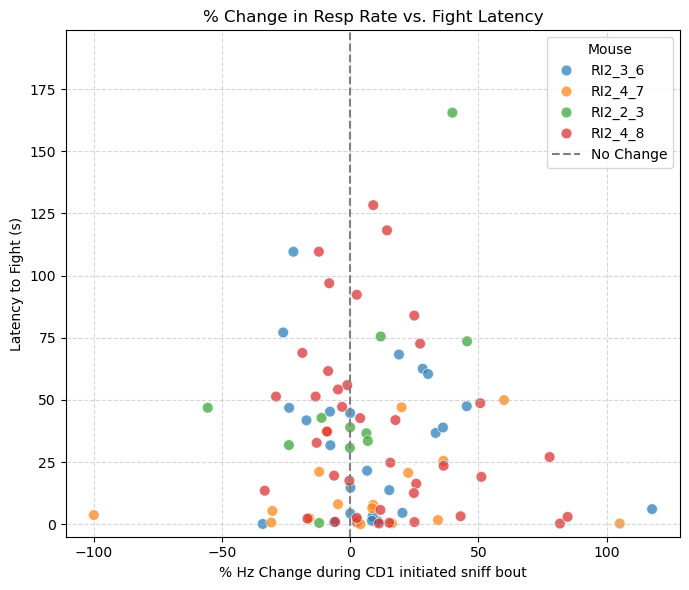

In [25]:
min_latency = -5
max_latency = all_mice_df["Latency (s)"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=all_mice_df,
    x="%Resp Rate Change",
    y="Latency (s)",
    hue="Mouse",  # <--- use 'Mouse' here
    palette="tab10",
    alpha=0.7,
    s=60
)

plt.axvline(0, linestyle='--', color='gray', label='No Change')

plt.xlabel("% Hz Change during CD1 initiated sniff bout")
plt.ylabel("Latency to Fight (s)")
plt.title("% Change in Resp Rate vs. Fight Latency")

plt.ylim(min_latency, max_latency + buffer)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Mouse")
plt.tight_layout()
plt.show()


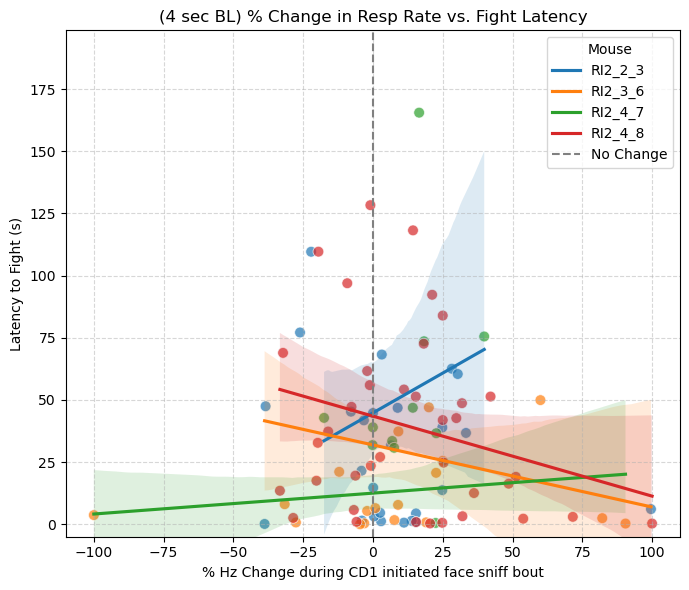

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

min_latency = -5
max_latency = all_mice_df["Latency (s)"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(7, 6))

# Scatterplot for all mice
sns.scatterplot(
    data=all_mice_df,
    x="%Resp Rate Change",
    y="Latency (s)",
    hue="Mouse",
    palette="tab10",
    alpha=0.7,
    s=60,
    legend=False  # we'll add custom legend below
)

# Add regression lines for each mouse
palette = sns.color_palette("tab10", n_colors=all_mice_df["Mouse"].nunique())
for i, (mouse, df_mouse) in enumerate(all_mice_df.groupby("Mouse")):
    df_clean = df_mouse.dropna(subset=["%Resp Rate Change", "Latency (s)"])
    if len(df_clean) > 1:
        sns.regplot(
            data=df_clean,
            x="%Resp Rate Change",
            y="Latency (s)",
            scatter=False,
            color=palette[i],
            label=f"{mouse}"
        )

plt.axvline(0, linestyle='--', color='gray', label='No Change')

plt.xlabel("% Hz Change during CD1 initiated face sniff bout")
plt.ylabel("Latency to Fight (s)")
plt.title("(4 sec BL) % Change in Resp Rate vs. Fight Latency")

plt.ylim(min_latency, max_latency + buffer)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Mouse")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
from scipy.stats import linregress

results = []

for mouse, df_mouse in all_mice_df.groupby("Mouse"):
    # Remove rows with missing values in the relevant columns
    df_clean = df_mouse.dropna(subset=["%Resp Rate Change", "Latency (s)"])
    
    if len(df_clean) > 1:  # Need at least 2 points for regression
        slope, intercept, r_value, p_value, std_err = linregress(
            df_clean["%Resp Rate Change"], df_clean["Latency (s)"]
        )
        results.append({
            "Mouse": mouse,
            "Slope": slope,
            "Intercept": intercept,
            "R-squared": r_value**2,
            "P-value": p_value,
            "Std Err": std_err,
            "N_points": len(df_clean)
        })
    else:
        results.append({
            "Mouse": mouse,
            "Slope": None,
            "Intercept": None,
            "R-squared": None,
            "P-value": None,
            "Std Err": None,
            "N_points": len(df_clean)
        })

stats_df = pd.DataFrame(results)
print(stats_df)


     Mouse     Slope  Intercept  R-squared   P-value   Std Err  N_points
0  RI2_2_3  0.639991  44.799026   0.050973  0.504443  0.920499        11
1  RI2_3_6 -0.249829  31.913284   0.052124  0.261956  0.217467        26
2  RI2_4_7  0.084043  12.530740   0.047108  0.386976  0.094496        18
3  RI2_4_8 -0.321738  43.492156   0.067294  0.115776  0.199635        38


In [ ]:
resp_rate_df = pd.DataFrame(results)
resp_rate_df


,Mouse,Slope,Intercept,R-squared,P-value,Std Err,N_points
0,RI2_2_3,0.639991,44.799026,0.050973,0.504443,0.920499,11
1,RI2_3_6,-0.249829,31.913284,0.052124,0.261956,0.217467,26
2,RI2_4_7,0.084043,12.530740,0.047108,0.386976,0.094496,18
3,RI2_4_8,-0.321738,43.492156,0.067294,0.115776,0.199635,38


In [ ]:
def get_windowed_percent_change_resp_rate(signal, times, event_start, sampling_rate=100):
    """
    Calculate percent change in respiratory rate from -1.5 to -0.5 s pre-event 
    to +0.5 to +1.5 s post-event.

    Parameters
    ----------
    signal : np.array
        Filtered respiration signal.
    times : np.array
        Time vector aligned with signal.
    event_start : float
        Start time of the behavioral event (e.g. sniff bout).
    sampling_rate : int, optional
        Signal sampling rate (Hz), default is 100.

    Returns
    -------
    percent_change : float
        Percent change in Hz from pre- to post-event. Returns np.nan if invalid.
    """
    # Define windows
    pre_start, pre_end = event_start - 1.5, event_start - 0.5
    post_start, post_end = event_start + 0.5, event_start + 1.5

    # Masks
    pre_mask = (times >= pre_start) & (times < pre_end)
    post_mask = (times >= post_start) & (times < post_end)

    signal_pre = signal[pre_mask]
    signal_post = signal[post_mask]

    # Safety checks
    if signal_pre.size == 0 or signal_post.size == 0:
        return np.nan

    min_distance = int(sampling_rate * 0.2)  # ~5 Hz max breathing

    # Detect peaks
    peaks_pre, _ = find_peaks(signal_pre, distance=min_distance)
    peaks_post, _ = find_peaks(signal_post, distance=min_distance)

    # Calculate breathing rates
    rate_pre = len(peaks_pre) / 1.0  # 1 second window
    rate_post = len(peaks_post) / 1.0

    if rate_pre == 0 or np.isnan(rate_pre):
        return np.nan

    # Percent change from pre to post
    percent_change = ((rate_post - rate_pre) / rate_pre) * 100

    return percent_change


In [ ]:
for _, row in all_mice_df.iterrows():
    sniff_start = row["Sniff Start Time (s)"]
    mouse_id = row["Mouse"]

    resp_entry = resp_data.get(mouse_id)
    if resp_entry:
        change = get_windowed_percent_change_resp_rate(
            resp_entry["signal"],
            resp_entry["time"],
            sniff_start,
            resp_entry["sampling_rate"]
        )
        # Store `change` somewhere



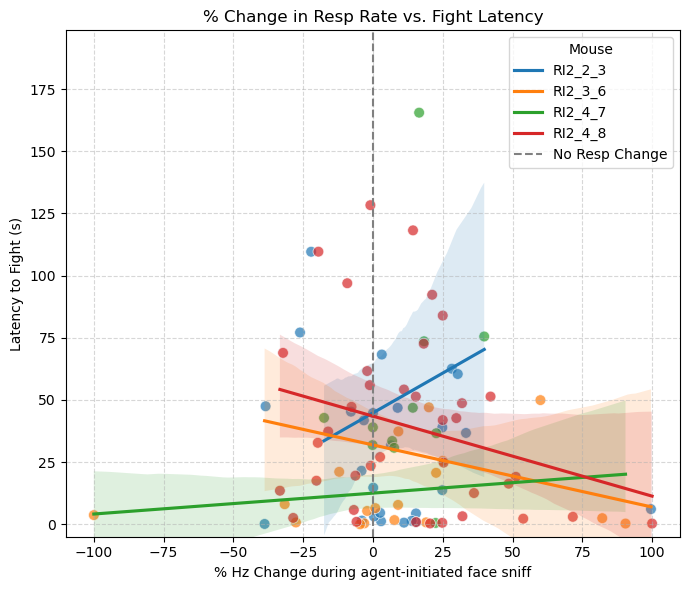

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute y-axis range with buffer
min_latency = -5
max_latency = all_mice_df["Latency (s)"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(7, 6))

# Scatterplot for all mice
sns.scatterplot(
    data=all_mice_df,
    x="%Resp Rate Change",
    y="Latency (s)",
    hue="Mouse",
    palette="tab10",
    alpha=0.7,
    s=60,
    legend=False  # We'll customize legend below
)

# Add regression lines per mouse
palette = sns.color_palette("tab10", n_colors=all_mice_df["Mouse"].nunique())
for i, (mouse, df_mouse) in enumerate(all_mice_df.groupby("Mouse")):
    df_clean = df_mouse.dropna(subset=["%Resp Rate Change", "Latency (s)"])
    if len(df_clean) > 1:
        sns.regplot(
            data=df_clean,
            x="%Resp Rate Change",
            y="Latency (s)",
            scatter=False,
            color=palette[i],
            label=mouse
        )

# Reference line at 0% change
plt.axvline(0, linestyle='--', color='gray', label='No Resp Change')

# Final formatting
plt.xlabel("% Hz Change during agent-initiated face sniff")
plt.ylabel("Latency to Fight (s)")
plt.title("% Change in Resp Rate vs. Fight Latency")
plt.ylim(min_latency, max_latency + buffer)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Mouse")
plt.tight_layout()
plt.show()

